In [25]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap
from ND2.utils import get_fig

df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['library_size'] = df['func_lib'].apply(len)
df['success'] = df['success'].apply(lambda x: eval(x))

df.groupby(['library_size', 'name']).count()

host  seed  time  success  RMSE  \
library_size name                                                              
49           Kuramoto_SNR-10                    9     9     9        9     9   
             Kuramoto_SNR-20                    9     9     9        9     9   
             Kuramoto_SNR0                      9     9     9        9     9   
             Kuramoto_SNR10                     9     9     9        9     9   
             Kuramoto_SNR20                     9     9     9        9     9   
...                                           ...   ...   ...      ...   ...   
227          MM_full_missing_link_ratio0.3      2     2     2        2     2   
             MM_full_missing_link_ratio0.4      2     2     2        2     2   
             MM_full_missing_link_ratio0.5      2     2     2        2     2   
             MM_full_missing_link_ratio0.6      2     2     2        2     2   
             MM_full_spurious_link_ratio0.0     2     2     2        2     2   

                                             MAPE  wMAPE  sMAPE  R2  ACC2  \
library_size name                                                           
49           Kuramoto_SNR-10                    9      9      9   9     9   
             Kuramoto_SNR-20                    9      9      9   9     9   
             Kuramoto_SNR0                      9      9      9   9     9   
             Kuramoto_SNR10                     9      9      9   9     9   
             Kuramoto_SNR20                     9      9      9   9     9   
...                                           ...    ...    ...  ..   ...   
227          MM_full_missing_link_ratio0.3      2      2      2   2     2   
             MM_full_missing_link_ratio0.4      2      2      2   2     2   
             MM_full_missing_link_ratio0.5      2      2      2   2     2   
             MM_full_missing_link_ratio0.6      2      2      2   2     2   
             MM_full_spurious_link_ratio0.0     2      2      2   2     2   

                                             ...  library  polynomial_order  \
library_size name                            ...                              
49           Kuramoto_SNR-10                 ...        9                 9   
             Kuramoto_SNR-20                 ...        9                 9   
             Kuramoto_SNR0                   ...        9                 9   
             Kuramoto_SNR10                  ...        9                 9   
             Kuramoto_SNR20                  ...        9                 9   
...                                          ...      ...               ...   
227          MM_full_missing_link_ratio0.3   ...        2                 2   
             MM_full_missing_link_ratio0.4   ...        2                 2   
             MM_full_missing_link_ratio0.5   ...        2                 2   
             MM_full_missing_link_ratio0.6   ...        2                 2   
             MM_full_spurious_link_ratio0.0  ...        2                 2   

                                             activation_alpha  \
library_size name                                               
49           Kuramoto_SNR-10                                9   
             Kuramoto_SNR-20                                9   
             Kuramoto_SNR0                                  9   
             Kuramoto_SNR10                                 9   
             Kuramoto_SNR20                                 9   
...                                                       ...   
227          MM_full_missing_link_ratio0.3                  2   
             MM_full_missing_link_ratio0.4                  2   
             MM_full_missing_link_ratio0.5                  2   
             MM_full_missing_link_ratio0.6                  2   
             MM_full_spurious_link_ratio0.0                 2   

                                             activation_beta  \
library_size name                                              


In [26]:
# df = df[df.name.str.contains('MM')] # MM 其实是 FHN，打错了
df = df[df.name.str.contains('Kuramoto')]

/tmp/ipykernel_1952017/1009491186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SNR['SNR'] = df_SNR['name'].str.extract(r'SNR(-?\d+)').astype(int)
/tmp/ipykernel_1952017/1009491186.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing['ratio'] = df_missing['name'].str.extract(r'ratio([0-9\.]+)').astype(float)
/tmp/ipykernel_1952017/1009491186.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

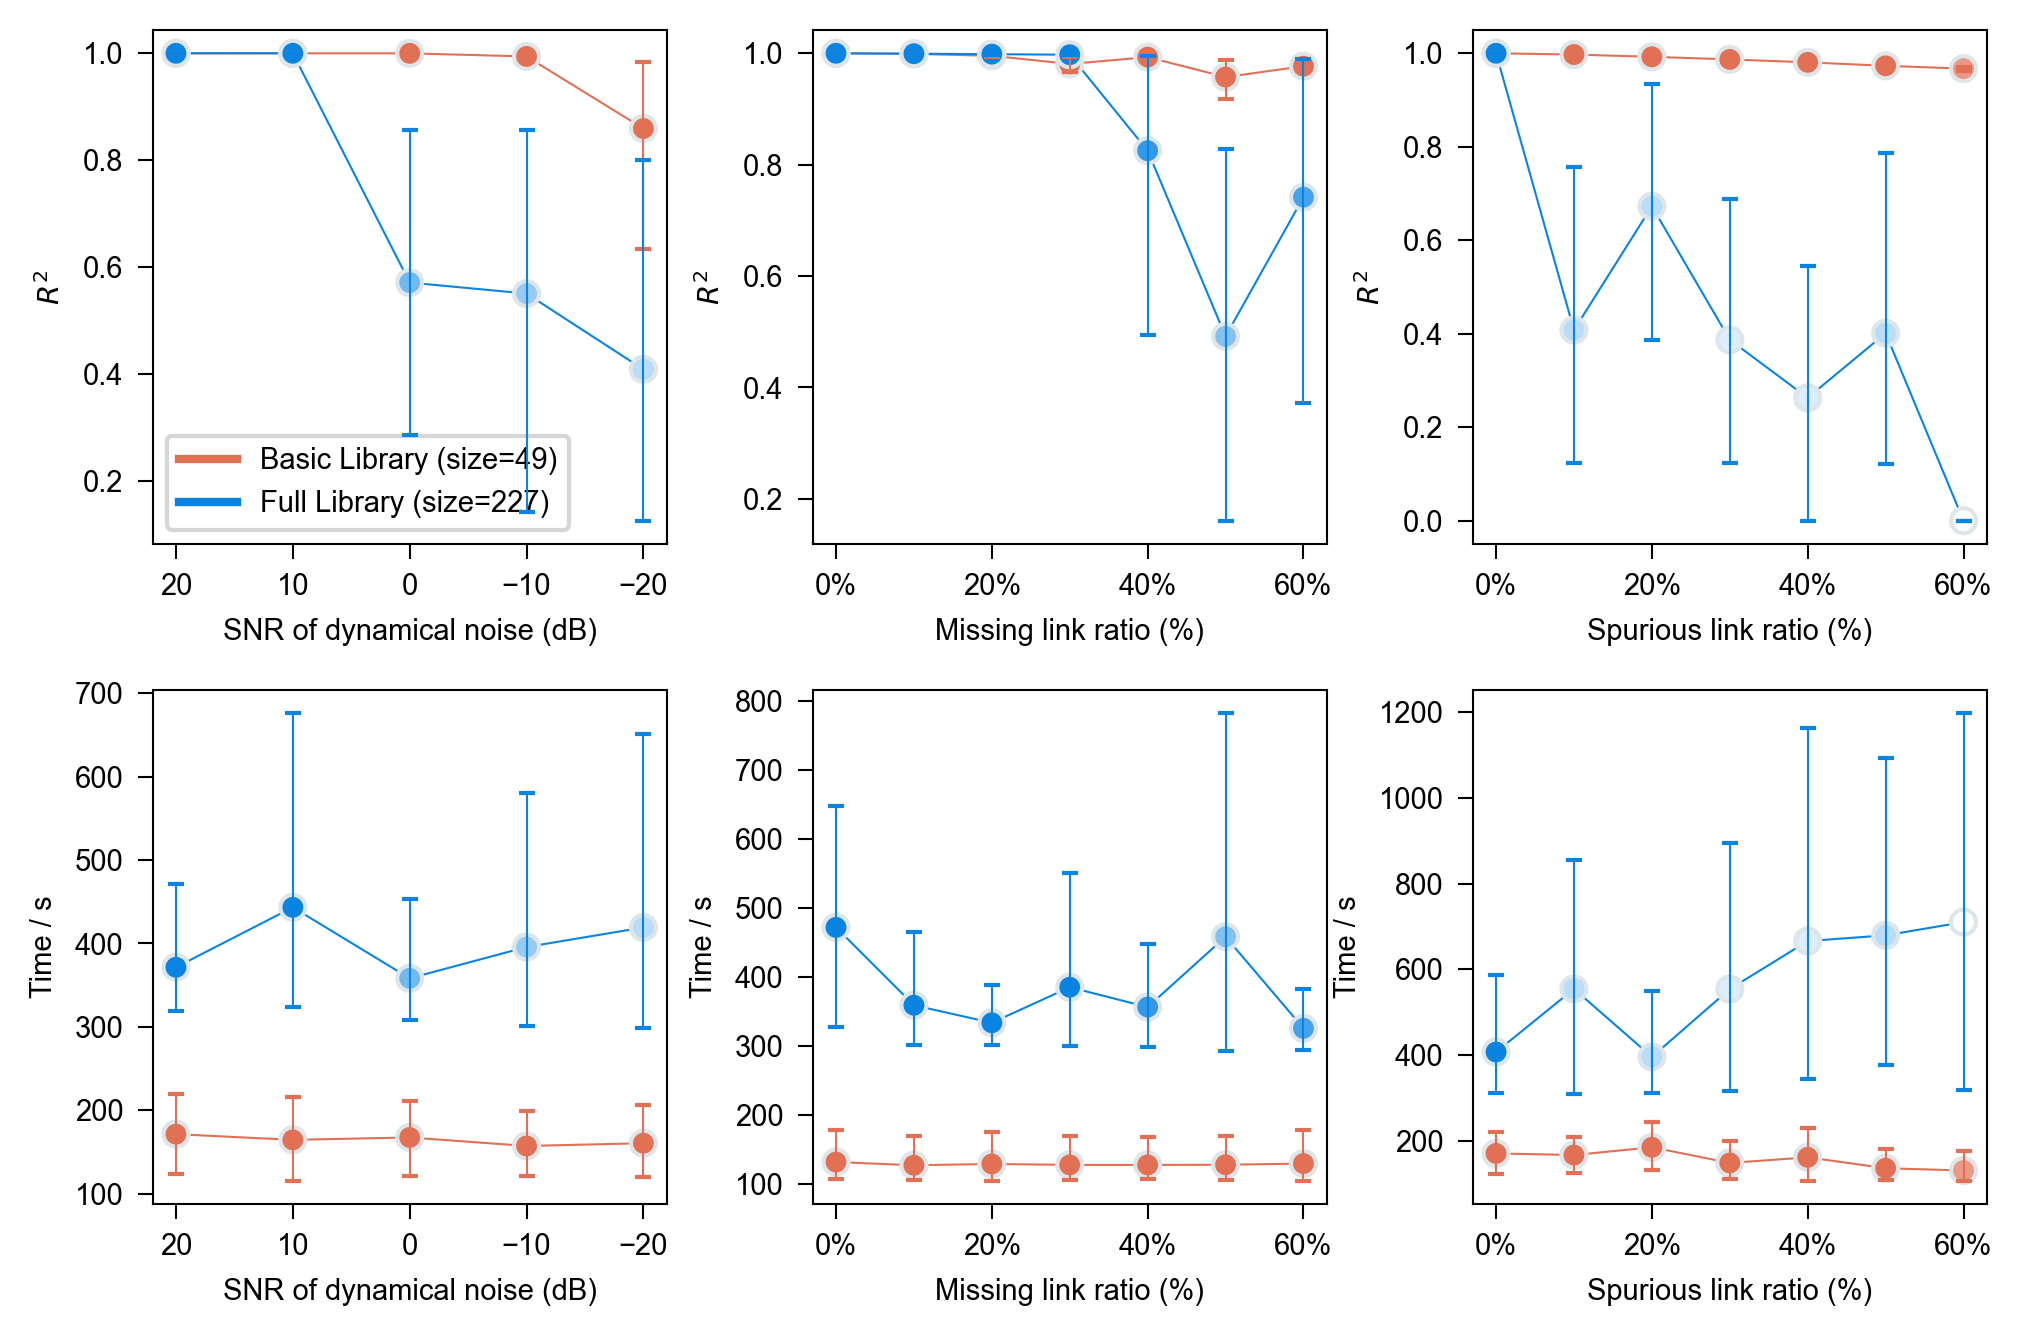

In [27]:
df_SNR = df[df.name.str.contains('SNR')]
df_SNR['SNR'] = df_SNR['name'].str.extract(r'SNR(-?\d+)').astype(int)

df_missing = df[df.name.str.contains('missing')]
df_missing['ratio'] = df_missing['name'].str.extract(r'ratio([0-9\.]+)').astype(float)

df_spurious = df[df.name.str.contains('spurious')]
df_spurious['ratio'] = df_spurious['name'].str.extract(r'ratio([0-9\.]+)').astype(float)

# library_sizes = df['library_size'].unique() # 29,  49, 227

fi, fig, axes = get_fig(2, 3, FW=18, LM=5, RM=5, TM=5, BM=5)

kwargs1 = dict(marker='o', lw=0.5, markersize=0, err_style='bars', err_kws={'capsize': 2, 'zorder':999999})
kwargs2 = dict(edgecolor=(0.8745, 0.9020, 0.9137, 1), linewidths=1, zorder=99999)
get_color = lambda color, value: LinearSegmentedColormap.from_list('my_cmap', ['#ffffff', color])(plt.Normalize(0, 1)(value))

ax = axes[0]
for library_size, color in zip([49, 227], ['#e17055', '#0984e3']):
    tmp = df_SNR[df_SNR['library_size'] == library_size]
    sns.lineplot(data=tmp, x='SNR', y='R2', ax=ax, color=color, **kwargs1)
    tmp = tmp.groupby('SNR')[['R2', 'success']].mean().reset_index()
    ax.scatter(tmp['SNR'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.invert_xaxis()
ax.set_xlabel('SNR of dynamical noise (dB)')
ax.set_ylabel('$R^2$')
ax.legend(
    [
        plt.Line2D([0], [0], color='#e17055', lw=2, label='Library size = 49'),
        plt.Line2D([0], [0], color='#0984e3', lw=2, label='Library size = 227')
    ],
    ['Basic Library (size=49)', 'Full Library (size=227)'],
)

ax = axes[1]
for library_size, color in zip([49, 227], ['#e17055', '#0984e3']):
    tmp = df_missing[df_missing['library_size'] == library_size]
    sns.lineplot(data=tmp, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
    tmp = tmp.groupby('ratio')[['R2', 'success']].mean().reset_index()
    ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_xlabel('Missing link ratio (%)')
ax.set_ylabel('$R^2$')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax = axes[2]
for library_size, color in zip([49, 227], ['#e17055', '#0984e3']):
    tmp = df_spurious[df_spurious['library_size'] == library_size]
    sns.lineplot(data=tmp, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
    tmp = tmp.groupby('ratio')[['R2', 'success']].mean().reset_index()
    ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_xlabel('Spurious link ratio (%)')
ax.set_ylabel('$R^2$')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax = axes[3]
for library_size, color in zip([49, 227], ['#e17055', '#0984e3']):
    tmp = df_SNR[df_SNR['library_size'] == library_size]
    sns.lineplot(data=tmp, x='SNR', y='time', ax=ax, color=color, **kwargs1)
    tmp = tmp.groupby('SNR')[['time', 'success']].mean().reset_index()
    ax.scatter(tmp['SNR'], tmp['time'], c=get_color(color, tmp['success']), **kwargs2)
ax.invert_xaxis()
ax.set_xlabel('SNR of dynamical noise (dB)')
ax.set_ylabel('Time / s')

ax = axes[4]
for library_size, color in zip([49, 227], ['#e17055', '#0984e3']):
    tmp = df_missing[df_missing['library_size'] == library_size]
    sns.lineplot(data=tmp, x='ratio', y='time', ax=ax, color=color, **kwargs1)
    tmp = tmp.groupby('ratio')[['time', 'success']].mean().reset_index()
    ax.scatter(tmp['ratio'], tmp['time'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_xlabel('Missing link ratio (%)')
ax.set_ylabel('Time / s')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax = axes[5]
for library_size, color in zip([49, 227], ['#e17055', '#0984e3']):
    tmp = df_spurious[df_spurious['library_size'] == library_size]
    sns.lineplot(data=tmp, x='ratio', y='time', ax=ax, color=color, **kwargs1)
    tmp = tmp.groupby('ratio')[['time', 'success']].mean().reset_index()
    ax.scatter(tmp['ratio'], tmp['time'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_xlabel('Spurious link ratio (%)')
ax.set_ylabel('Time / s')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

os.makedirs('./plot/robustness', exist_ok=True)
fig.savefig('./plot/robustness/two_phase_robustness.pdf', bbox_inches='tight', dpi=300)

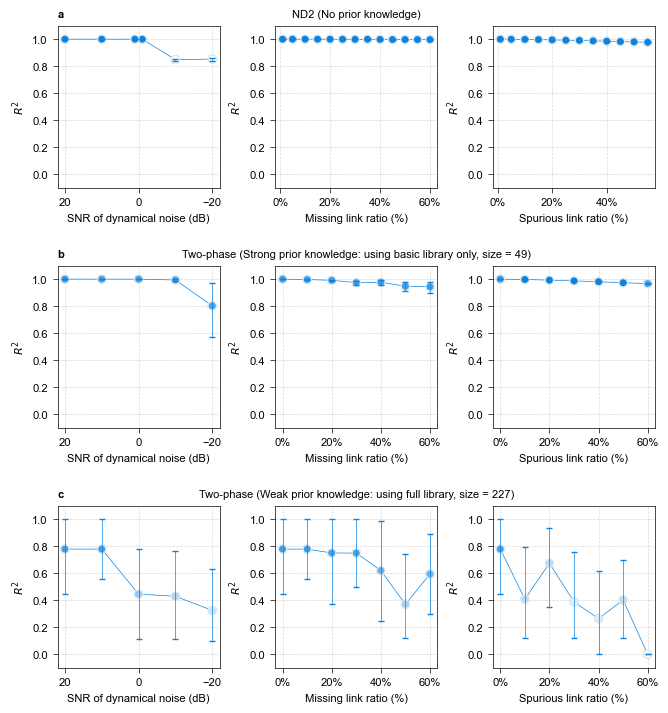

In [88]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap
from ND2.utils import get_fig

kwargs1 = dict(marker='o', lw=0.5, markersize=0, err_style='bars', err_kws={'capsize': 2, 'zorder':999999})
kwargs2 = dict(edgecolor=(0.8745, 0.9020, 0.9137, 1), linewidths=1, zorder=99999)
get_color = lambda color, value: LinearSegmentedColormap.from_list('my_cmap', ['#ffffff', color])(plt.Normalize(0, 1)(value))
fi, fig, axes = get_fig(3, 3, FW=18, LM=5, RM=5, TM=5, BM=5, VS=7, dpi=100, fontsize=8)

ax = axes[0]
color = '#0984e3'
df = pd.read_json('./result/robustness.jsonl', lines=True)
df['R2'] = df['R2'].clip(lower=0, upper=1)
sns.lineplot(data=df, x='SNR', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('SNR')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['SNR'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.invert_xaxis()
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('SNR of dynamical noise (dB)')
ax.set_ylabel('$R^2$')
ax.text(0.0, 1.1, 'a', transform=ax.transAxes, fontsize=fi['fontsize'], fontweight='bold', va='top', ha='left')

ax = axes[1]
color = '#0984e3'
df = pd.read_csv('./result/missing_link.csv', sep='\t')
df['R2'] = df['R2'].clip(lower=0, upper=1)
sns.lineplot(data=df, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('ratio')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_ylim(-0.1, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Missing link ratio (%)')
ax.set_ylabel('$R^2$')
ax.set_title('ND2 (No prior knowledge)')

ax = axes[2]
color = '#0984e3'
df = pd.read_csv('./result/spurious_link.csv', sep='\t')
df['R2'] = df['R2'].clip(lower=0, upper=1)
sns.lineplot(data=df, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('ratio')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_ylim(-0.1, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Spurious link ratio (%)')
ax.set_ylabel('$R^2$')


ax = axes[3]
color = '#0984e3'
df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df = df[df.name.str.contains('SNR')]
df = df[df.func_lib.apply(len) == 49].copy()
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['SNR'] = df['name'].str.extract(r'SNR(-?\d+)').astype(int)
df['success'] = df['success'].apply(lambda x: eval(x))
sns.lineplot(data=df, x='SNR', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('SNR')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['SNR'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.invert_xaxis()
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('SNR of dynamical noise (dB)')
ax.set_ylabel('$R^2$')
ax.text(0.0, 1.1, 'b', transform=ax.transAxes, fontsize=fi['fontsize'], fontweight='bold', va='top', ha='left')

ax = axes[4]
color = '#0984e3'
df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df = df[df.name.str.contains('missing')]
df = df[df.func_lib.apply(len) == 49].copy()
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['ratio'] = df['name'].str.extract(r'ratio([0-9\.]+)').astype(float)
df['success'] = df['success'].apply(lambda x: eval(x))
sns.lineplot(data=df, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('ratio')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_ylim(-0.1, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Missing link ratio (%)')
ax.set_ylabel('$R^2$')
ax.set_title('Two-phase (Strong prior knowledge: using basic library only, size = 49)')

ax = axes[5]
color = '#0984e3'
df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df = df[df.name.str.contains('spurious')]
df = df[df.func_lib.apply(len) == 49].copy()
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['ratio'] = df['name'].str.extract(r'ratio([0-9\.]+)').astype(float)
df['success'] = df['success'].apply(lambda x: eval(x))
sns.lineplot(data=df, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('ratio')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_ylim(-0.1, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Spurious link ratio (%)')
ax.set_ylabel('$R^2$')


ax = axes[6]
color = '#0984e3'
df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df = df[df.name.str.contains('SNR')]
df = df[df.func_lib.apply(len) == 227].copy()
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['SNR'] = df['name'].str.extract(r'SNR(-?\d+)').astype(int)
df['success'] = df['success'].apply(lambda x: eval(x))
sns.lineplot(data=df, x='SNR', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('SNR')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['SNR'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.invert_xaxis()
ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('SNR of dynamical noise (dB)')
ax.set_ylabel('$R^2$')
ax.text(0.0, 1.1, 'c', transform=ax.transAxes, fontsize=fi['fontsize'], fontweight='bold', va='top', ha='left')

ax = axes[7]
color = '#0984e3'
df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df = df[df.name.str.contains('missing')]
df = df[df.func_lib.apply(len) == 227].copy()
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['ratio'] = df['name'].str.extract(r'ratio([0-9\.]+)').astype(float)
df['success'] = df['success'].apply(lambda x: eval(x))
sns.lineplot(data=df, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('ratio')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_ylim(-0.1, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Missing link ratio (%)')
ax.set_ylabel('$R^2$')
ax.set_title('Two-phase (Weak prior knowledge: using full library, size = 227)')

ax = axes[8]
color = '#0984e3'
df = pd.read_json('./result/baseline_NCS22.jsonl', lines=True)
df = df[df.name.str.contains('spurious')]
df = df[df.func_lib.apply(len) == 227].copy()
df['R2'] = df['R2'].clip(lower=0, upper=1)
df['ratio'] = df['name'].str.extract(r'ratio([0-9\.]+)').astype(float)
df['success'] = df['success'].apply(lambda x: eval(x))
sns.lineplot(data=df, x='ratio', y='R2', ax=ax, color=color, **kwargs1)
tmp = df.groupby('ratio')[['R2', 'success']].mean().reset_index()
ax.scatter(tmp['ratio'], tmp['R2'], c=get_color(color, tmp['success']), **kwargs2)
ax.set_ylim(-0.1, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Spurious link ratio (%)')
ax.set_ylabel('$R^2$')

for ax in axes:
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.savefig('./plot/robustness/robustness_compare.pdf', bbox_inches='tight', dpi=300)